In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models,layers
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!zip -r /content/plantvillage.zip "/content/drive/MyDrive/PlantVillage"

  adding: content/drive/MyDrive/PlantVillage/ (stored 0%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/ (stored 0%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/09ab9573-90d5-4001-9b74-14551935deef___RS_Early.B 7603.JPG (deflated 1%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/04ee51b6-07e2-4182-84f8-46b22c8938a2___RS_Early.B 8091.JPG (deflated 1%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/048d18ae-98b1-484d-97da-5a0e69b9ebc1___RS_Early.B 6845.JPG (deflated 1%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/05c35093-11b8-4cd0-b67a-148859754440___RS_Early.B 8939.JPG (deflated 1%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/065fc68f-88c9-4fc3-b0a6-a6f5e1072eaa___RS_Early.B 7174.JPG (deflated 1%)
  adding: content/drive/MyDrive/PlantVillage/Potato___Early_blight/0182e991-97f0-4805-a1f7-6e1b4306d518___RS_Early.B 7015.JPG (deflated 1%)
  adding: content/driv

In [4]:
!unzip -q /content/plantvillage.zip -d /content/local_plantvillage

In [21]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/local_plantvillage/content/drive/MyDrive/PlantVillage",
    shuffle=True,
    image_size = (256,256),
    batch_size = 32

)

Found 2152 files belonging to 3 classes.


In [22]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [23]:
len(dataset)

68

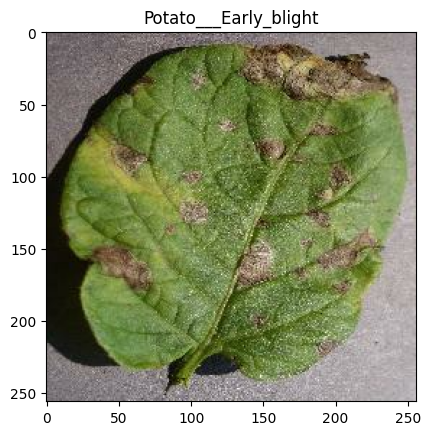

In [24]:
for image_batch, label_batch in dataset.take(1):
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(class_names[label_batch[0]])




In [25]:
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1,test_split= 0.1, shuffle=True, shuffle_size= 10000):

    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)


    return train_ds,val_ds,test_ds


In [26]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [27]:
len(train_ds)

54

In [28]:
len(val_ds)

6

In [29]:
len(test_ds)

8

In [30]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [31]:
scale = tf.keras.Sequential([
    layers.Resizing(256,256),
    layers.Rescaling(1.0/255)
])

In [32]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [33]:

n_classes = 3

model = models.Sequential([
    scale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),activation='relu',),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.build()

In [34]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [35]:
model.fit(
    train_ds,
    epochs =50,
    batch_size = 32,
    validation_data = val_ds,
    verbose = 1
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.4797 - loss: 0.9198 - val_accuracy: 0.6823 - val_loss: 0.8736
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.5951 - loss: 0.8081 - val_accuracy: 0.7024 - val_loss: 0.6340
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.7535 - loss: 0.5684 - val_accuracy: 0.7760 - val_loss: 0.5208
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.8110 - loss: 0.4402 - val_accuracy: 0.8385 - val_loss: 0.4536
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.8721 - loss: 0.3208 - val_accuracy: 0.8646 - val_loss: 0.2762
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.8991 - loss: 0.2574 - val_accuracy: 0.8490 - val_loss: 0.4817
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.8938 - loss: 0.2547 - val_accuracy: 0.8177 - val_loss: 0.4212
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9167 - loss: 0.2220 - val_accuracy: 0.9219 

In [36]:
score = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9844 - loss: 0.0377


In [37]:
score

[0.037704627960920334, 0.984375]

First image to predict
Actual label:  Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted label:  Potato___Early_blight


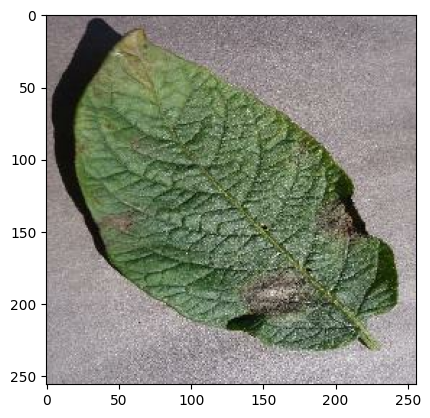

In [42]:
import numpy as np


for images_batch, labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print("First image to predict")
  plt.imshow(first_image)
  print("Actual label: ",class_names[first_label])

  batch_prediction = model.predict(image_batch)
  print("Predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [43]:
def predict(model, img):
  img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array = tf.expand_dims(img_array, 0)

  predictions = model.predict(img_array)

  predicted_class = class_names[np.argmax(predictions[0])]
  confidence = round(100 * (np.max(predictions[0])), 2)
  return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


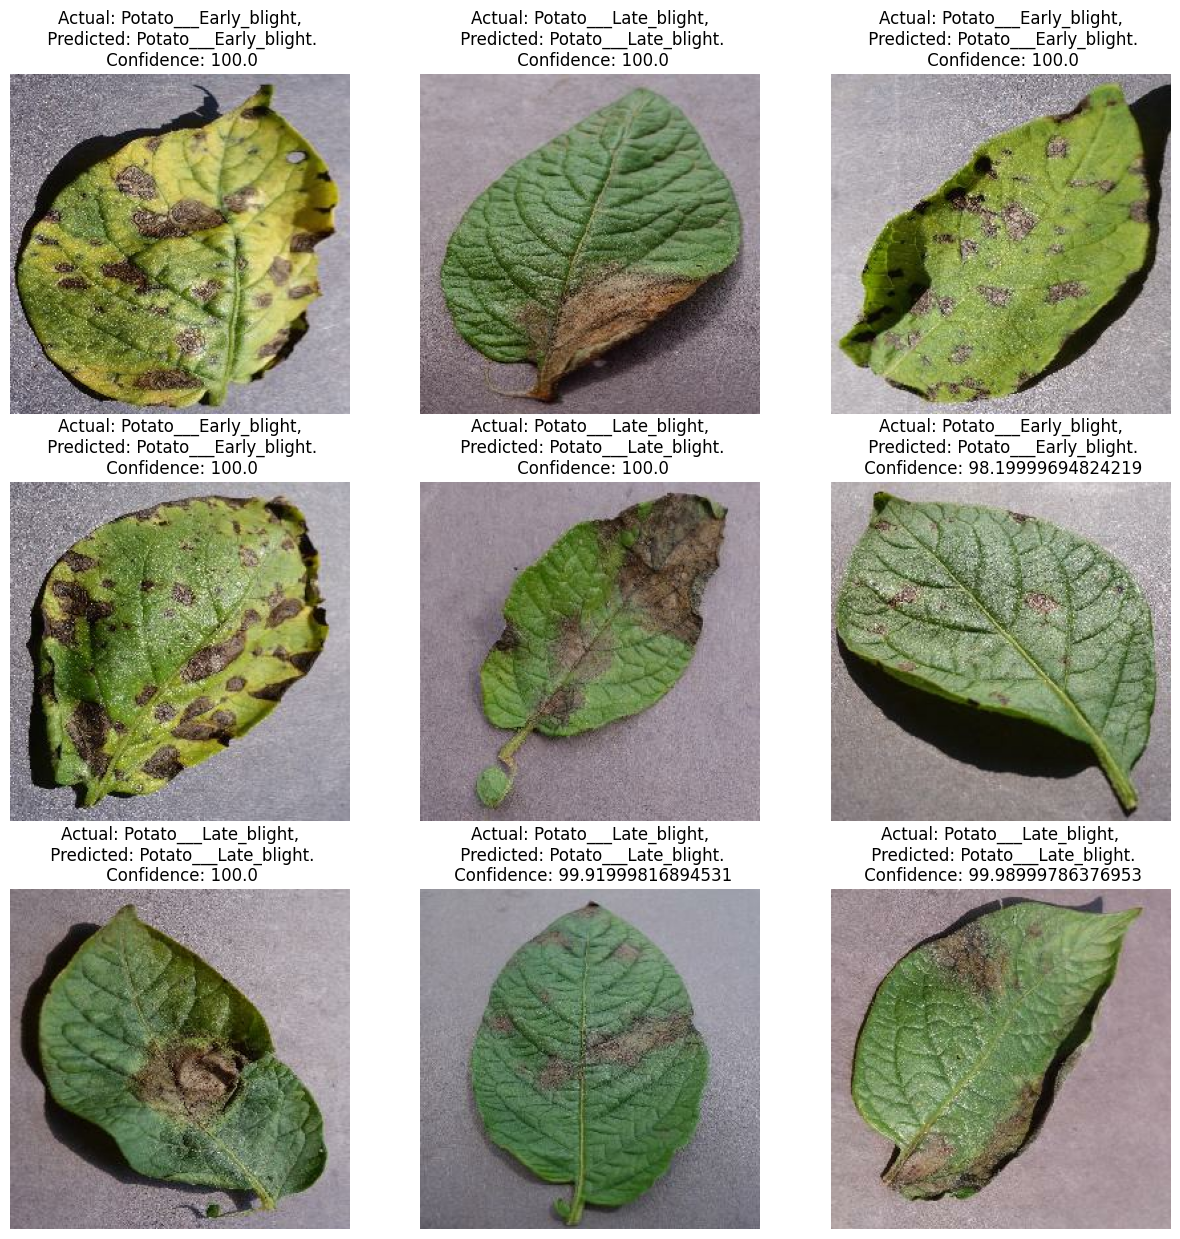

In [47]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}")

    plt.axis("off")